# **Project Introduction & Business Rationale**

Effective decision-making relies on a deep, data-driven understanding of passenger usage patterns, model performance, and trip characteristics. This project simulates a real-world data science pipeline by transforming raw, unrefined transit data into strategic intelligence for MetroMove.

Through rigorous data preprocessing, targeted feature engineering, and visual exploratory data analysis (EDA), this notebook uncovers critical operational trends, exposes system inefficiencies, and delivers clear, actionable insights to optimize transit fleet scheduling and pricing structures.

In [ ]:
import pandas as pd # data preprocessing
import numpy as np
import seaborn as sns # data visualisation
import matplotlib.pyplot as plt # data visaulisation
import missingno as msno # missing data - data visualisation
import collections as counter # counter

In [ ]:
# load the dataset
df = pd.read_excel('/content/Public_Transport_Trips_EDA (1).xlsx')

**Column/Description**

1.   **Trip_ID:** Unique identifier for each trip
2.  **Mode_of_Transport:** Type of transport used: Bus, Train, Ferry, or Tram (includes inconsistencies)
3.   **Departure_Station:** Station where the trip starts (contains whitespace errors)
4.  **Arrival_Station:** Station where the trip ends (inconsistent casing)
5.  **Departure_Time:** Exact date and time when the trip departed
6.  **Passenger_Count:** Number of passengers on the trip (includes missing values)
7.  **Fare_Amount:** Amount paid by the passengers for the trip (includes missing values)
8. **Trip_Duration_Minutes:** Duration of the trip in minutes (includes missing values)
9. **Trip_Date:** Date on which the trip occurred
10. **Day_of_Week:** Day of the week on which the trip occurred






**Initial Data Inspect**

In [ ]:
# print the top 5 row
df.head(5)

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
0,TRIP0001,FERRY,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,NaN,F
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,NaN,F
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday,NaN,F
3,TRIP0004,FERRY,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,NaN,2024-01-01,Sunday,NaN,F
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,NaN,NaN,2024-01-01,Monday,NaN,F


In [ ]:
# print the botton row
df.tail()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
995,TRIP0996,train,North Station,West End,2024-01-01 22:35:00,NaN,40.546670,51.0,2024-02-11,Saturday,NaN,NaN
996,TRIP0997,Bus,Central,West End,2024-01-01 22:36:00,63.0,7.772635,35.0,2024-02-11,Thursday,NaN,NaN
997,TRIP0998,FERRY,West End,North Station,2024-01-01 22:37:00,23.0,NaN,8.0,2024-02-11,Saturday,NaN,NaN
998,TRIP0999,Tram,South Point,Central,2024-01-01 22:38:00,9.0,43.300617,169.0,2024-02-11,Sunday,NaN,NaN
999,TRIP1000,train,Airport,West End,2024-01-01 22:39:00,34.0,8.168803,21.0,2024-02-11,Tuesday,NaN,NaN


In [ ]:
# dimensionality of the data - the number of rows and columns
df.shape

(1000, 12)

In [ ]:
# examine the column/features of the data
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Unnamed: 10',
       'Unnamed: 11'],
      dtype='object')

In [ ]:
# investigate the dataset for datatypes/annomalies
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Trip_ID                1000 non-null   object        
 1   Mode_of_Transport      1000 non-null   object        
 2   Departure_Station      1000 non-null   object        
 3   Arrival_Station        1000 non-null   object        
 4   Departure_Time         1000 non-null   datetime64[ns]
 5   Passenger_Count        900 non-null    float64       
 6   Fare_Amount            900 non-null    float64       
 7   Trip_Duration_Minutes  900 non-null    float64       
 8   Trip_Date              1000 non-null   datetime64[ns]
 9   Day_of_Week            1000 non-null   object        
 10  Unnamed: 10            0 non-null      float64       
 11  Unnamed: 11            299 non-null    object        
dtypes: datetime64[ns](2), float64(4), object(6)
memory usage: 93.9+

In [ ]:
# numerical statistics analysis
df.describe()

,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Unnamed: 10
count,1000,900.000000,900.000000,900.000000,1000,0.0
mean,2024-01-01 14:19:30,49.154444,25.360742,94.270000,2024-01-21 08:03:50.400000,NaN
min,2024-01-01 06:00:00,1.000000,0.500576,5.000000,2024-01-01 00:00:00,NaN
25%,2024-01-01 10:09:45,25.000000,12.818196,49.750000,2024-01-11 00:00:00,NaN
50%,2024-01-01 14:19:30,48.000000,25.403856,97.500000,2024-01-21 00:00:00,NaN
75%,2024-01-01 18:29:15,72.000000,37.866623,138.000000,2024-02-01 00:00:00,NaN
max,2024-01-01 22:39:00,99.000000,49.945184,179.000000,2024-02-11 00:00:00,NaN
std,NaN,27.698270,14.464556,50.634982,NaN,NaN


In [ ]:
# catigorical statistics analysis
df.describe(include=['object','bool'])

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Day_of_Week,Unnamed: 11
count,1000,1000,1000,1000,1000,299
unique,1000,9,7,7,7,2
top,TRIP1000,Bus,North Station,South Point,Sunday,F
freq,1,147,171,171,167,250


**Text Standisation**

In [ ]:
# Remove whitespace and Add Proper Case to string value
text_columns = ['Mode_of_Transport', 'Departure_Station', 'Arrival_Station', 'Day_of_Week']
for column in text_columns:
  df[column] = df[column].str.strip().str.title()

In [ ]:
df[['Mode_of_Transport', 'Departure_Station', 'Arrival_Station', 'Day_of_Week']].head()

,Mode_of_Transport,Departure_Station,Arrival_Station,Day_of_Week
0,Ferry,West End,Airport,Sunday
1,Tram,North Station,Downtown,Saturday
2,Bus,Central,North Station,Tuesday
3,Ferry,Downtown,Central,Sunday
4,Ferry,Downtown,Central,Monday


**Visualising/Dealing with missing data**

1. MCAR (Missing completely at random): These are values that are randomly missing and do not depend on any other values.
2. MAR (Missing at random): These values are dependent on some additional features
3. MNAR (Missing not at random): There is a reason behind why these values are missing.

There are several methods for imputing missing data, including the measure of central of tendency involves replacing missing values with either the mean, median, mode of the variable, while regression imputaion involves using other variable in the dataset to predict missing values.

In [ ]:
# investigate the missing data
null_vals = df.isnull().sum()
null_vals

,0
Trip_ID,0
Mode_of_Transport,0
Departure_Station,0
Arrival_Station,0
Departure_Time,0
Passenger_Count,100
Fare_Amount,100
Trip_Duration_Minutes,100
Trip_Date,0
Day_of_Week,0


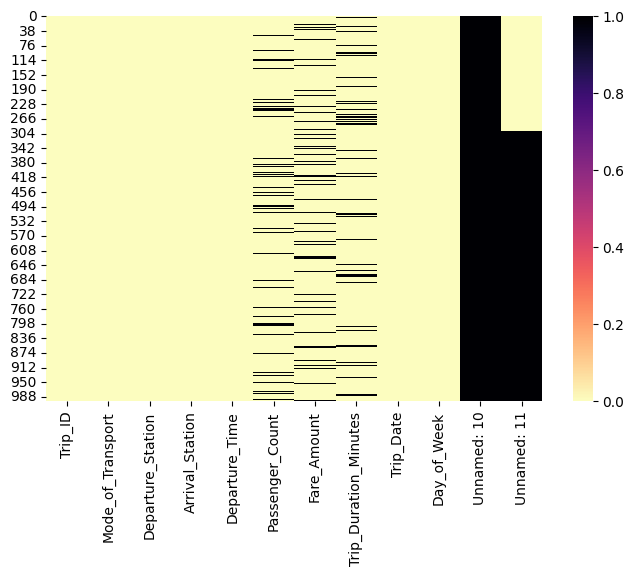

In [ ]:
# visualise missing data
plt.figure(figsize = (8,5))
sns.heatmap(df.isnull(), cbar=True, cmap='magma_r');

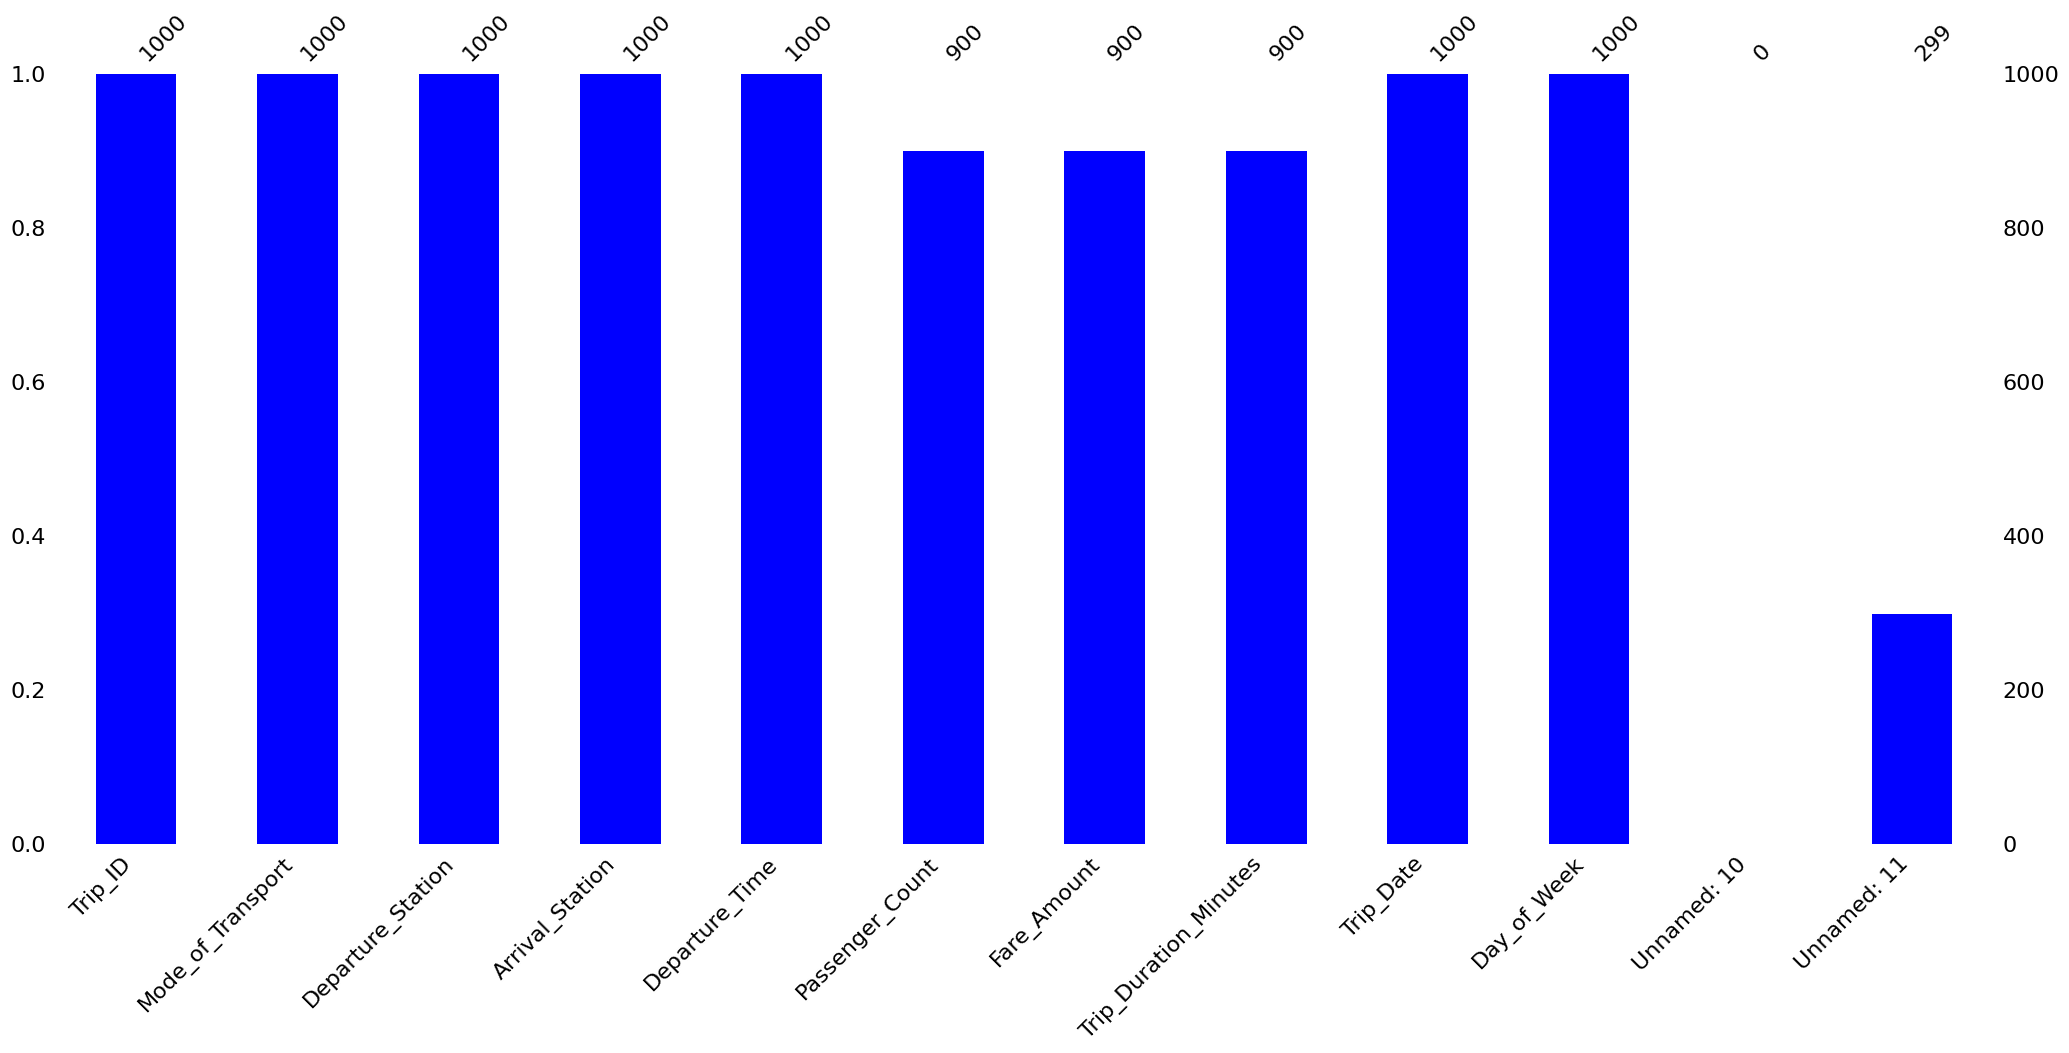

In [ ]:
# Visualising missing data
msno.bar(df, color="blue");

In [ ]:
# Redisplay where missing data exist in the data
df[df.isnull().any(axis=1)]

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
0,TRIP0001,Ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,NaN,F
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,NaN,F
2,TRIP0003,Bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday,NaN,F
3,TRIP0004,Ferry,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,NaN,2024-01-01,Sunday,NaN,F
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,NaN,NaN,2024-01-01,Monday,NaN,F
...,...,...,...,...,...,...,...,...,...,...,...,...
995,TRIP0996,Train,North Station,West End,2024-01-01 22:35:00,NaN,40.546670,51.0,2024-02-11,Saturday,NaN,NaN
996,TRIP0997,Bus,Central,West End,2024-01-01 22:36:00,63.0,7.772635,35.0,2024-02-11,Thursday,NaN,NaN
997,TRIP0998,Ferry,West End,North Station,2024-01-01 22:37:00,23.0,NaN,8.0,2024-02-11,Saturday,NaN,NaN
998,TRIP0999,Tram,South Point,Central,2024-01-01 22:38:00,9.0,43.300617,169.0,2024-02-11,Sunday,NaN,NaN


In [ ]:
# Drop Unknown column names 'Unnamed: 10','Unnamed: 11'
df.drop(['Unnamed: 10','Unnamed: 11'], axis=1, inplace=True)

In [ ]:
# Redisplay rows where missing value occured
df[df.isnull().any(axis=1)]

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week
2,TRIP0003,Bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday
3,TRIP0004,Ferry,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,NaN,2024-01-01,Sunday
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,NaN,NaN,2024-01-01,Monday
7,TRIP0008,Ferry,Central,South Point,2024-01-01 06:07:00,9.0,NaN,14.0,2024-01-01,Saturday
21,TRIP0022,Train,North Station,South Point,2024-01-01 06:21:00,16.0,NaN,26.0,2024-01-01,Monday
...,...,...,...,...,...,...,...,...,...,...
982,TRIP0983,Train,Airport,Airport,2024-01-01 22:22:00,25.0,48.404193,NaN,2024-02-10,Monday
984,TRIP0985,Train,South Point,Central,2024-01-01 22:24:00,1.0,14.279240,NaN,2024-02-11,Sunday
985,TRIP0986,Train,Downtown,Downtown,2024-01-01 22:25:00,15.0,NaN,47.0,2024-02-11,Sunday
995,TRIP0996,Train,North Station,West End,2024-01-01 22:35:00,NaN,40.546670,51.0,2024-02-11,Saturday


In [ ]:
# Cal the median for each mode of transport using passenger_count
Mot_medians = df.groupby('Mode_of_Transport')['Passenger_Count'].transform('median')
Mot_medians

,Passenger_Count
0,48.0
1,49.0
2,48.0
3,48.0
4,48.0
...,...
995,45.5
996,48.0
997,48.0
998,49.0


In [ ]:
# Fill missing value with medians
df['Passenger_Count'] = df['Passenger_Count'].fillna(Mot_medians).astype(float)

In [ ]:
# Cal the median for each transport mode using fare_amount
Fa_medians = df.groupby('Mode_of_Transport')['Fare_Amount'].transform('median')

# Fill missing values Tdm_medians and convert to float
df['Fare_Amount'] = df['Fare_Amount'].fillna(Fa_medians).astype(float)

In [ ]:
Tdm_medians = df.groupby('Mode_of_Transport')['Trip_Duration_Minutes'].transform('median')

df['Trip_Duration_Minutes'] = df['Trip_Duration_Minutes'].fillna(Tdm_medians).astype(float)

In [ ]:
df.isnull().sum()

,0
Trip_ID,0
Mode_of_Transport,0
Departure_Station,0
Arrival_Station,0
Departure_Time,0
Passenger_Count,0
Fare_Amount,0
Trip_Duration_Minutes,0
Trip_Date,0
Day_of_Week,0


**Visual Exploratory Data Analysis (EDA)**

The next section conduct a Visual Exploratory Data Analysis (EDA). The target is data visulisation across univariate, bivariate, and multivariate layers to uncover operational trends and customer patterns.

**Univariate Anaylysis**

Univariate Analysis involves analysing the distribution and summary statistics of individual variable/column/feature.

- Numerical column/feature = Numerical Visualisation Techniques
- Categorical columns/feature = categorical visualisation Techniques

In [ ]:
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week'],
      dtype='object')

In [ ]:
df.describe()

,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date
count,1000,1000.000000,1000.000000,1000.00000,1000
mean,2024-01-01 14:19:30,48.970500,25.383848,94.53500,2024-01-21 08:03:50.400000
min,2024-01-01 06:00:00,1.000000,0.500576,5.00000,2024-01-01 00:00:00
25%,2024-01-01 10:09:45,28.000000,13.917364,55.00000,2024-01-11 00:00:00
50%,2024-01-01 14:19:30,48.000000,26.165572,99.00000,2024-01-21 00:00:00
75%,2024-01-01 18:29:15,70.000000,36.580122,132.25000,2024-02-01 00:00:00
max,2024-01-01 22:39:00,99.000000,49.945184,179.00000,2024-02-11 00:00:00
std,NaN,26.284525,13.727316,48.05049,NaN


**Numerical Data Visualisation**

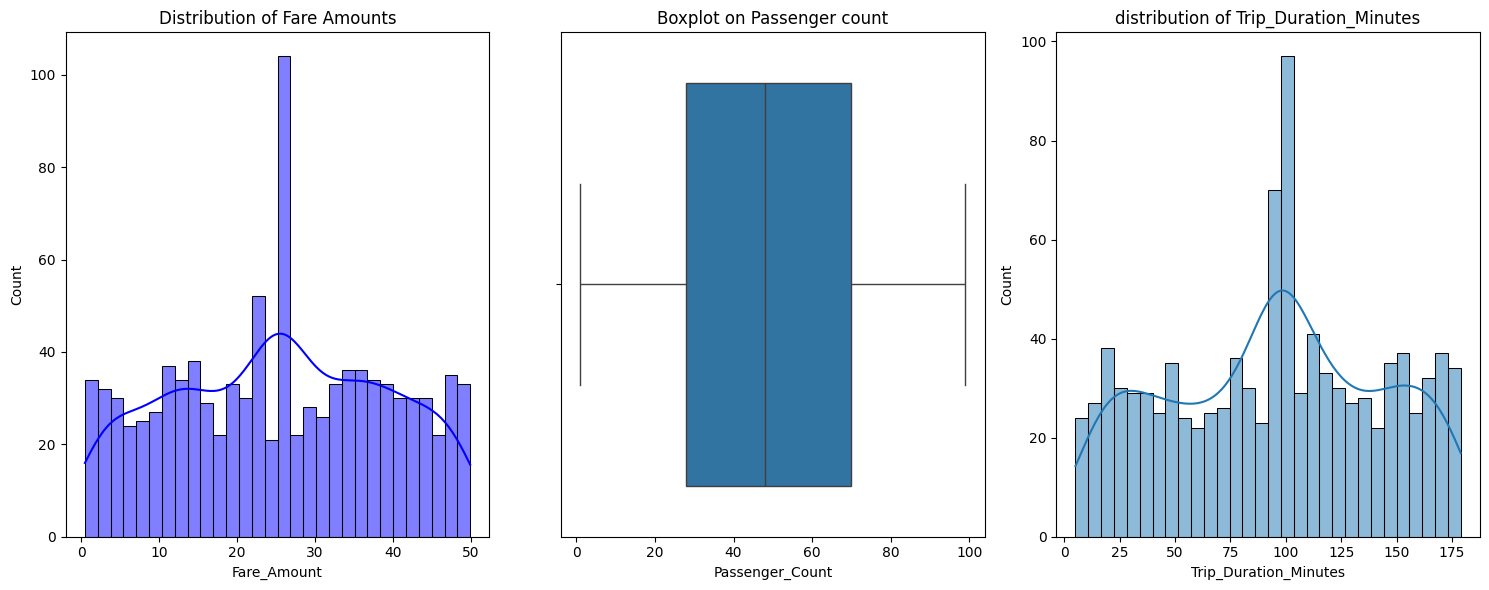

In [ ]:
# Numerical Data Visualisation : Passenger_Count, Fare_Amount

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))
sns.histplot(data=df, x='Fare_Amount', kde=True, bins=30, color='blue', ax=axs[0])
axs[0].set_title('Distribution of Fare Amounts')

sns.boxplot(data=df, x='Passenger_Count', ax=axs[1])
axs[1].set_title('Boxplot on Passenger count')

sns.histplot(data=df, x='Trip_Duration_Minutes',kde=True, bins=30, ax=axs[2])
axs[2].set_title('distribution of Trip_Duration_Minutes')
plt.tight_layout()


**Distribution of Fare Amounts**

- **The Insight:** Ticket prices are evenly spread out, from 1 to 50 pound. However a massive spike occured right in the middle around 26.

- **Data Imputation Footprint:** This is not natural customer trend, it is actually a footprint from the data cleaning. Because fare missing value filled with median, a large cluster of trips artificially snapped to this exact price point.

**Passenger Count Boxplot**

- **The Insight:** The passenger count shows a perfect balanced distribution ranging from 1 to nearly 100 passenger per trip, with absolutely no outliers present.

- **Capacity Metric/ Business Implications:** The upper quartile (Q3) sits right around 70, meaning that 75% of all recorded trips carried fewer than 70 passengers. This indicates that the vast majority of MetroMove's transit operates well below maximum capacity. While this avoids overcrowding, running large vehicles like trains and ferries with so few passengers represents a major operational inefficiency for management.

**Distribution of Trip Duration Minutes**

- **The Insight:** Trip durations are uniformly spread between 5 and 180 minutes. The prominent spike centered perfectly at 100 minutes is a direct artifact of the data cleaning, where missing values were systematically filled using the group median, creating an artificial peak at the center.

**Categorical Variables**

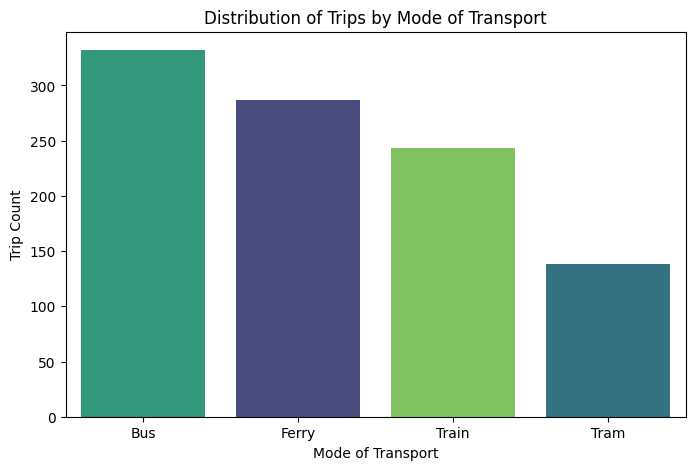

In [ ]:
# Categorical Variables

# Plot distribution of transport modes
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Mode_of_Transport',order=df['Mode_of_Transport'].value_counts(ascending=False).index, hue="Mode_of_Transport", legend=False, palette='viridis')
plt.title('Distribution of Trips by Mode of Transport')
plt.xlabel('Mode of Transport')
plt.ylabel('Trip Count')
plt.show()

**Distribution of Trips by Mode of Transport**

Buses leading the pack with 322 trips, closely followed by Ferries and Trains. On the other hand, Trams are our least utilized service, pulling in just under 140 trips. This gives management an immediate look at where our operational demand is concentrated.

In [ ]:
# Most frequent Mode of Transportation
df['Mode_of_Transport'].value_counts().head(10)

,count
Mode_of_Transport,
Bus,332
Ferry,287
Train,243
Tram,138


In [ ]:
df.describe(include=['object', 'bool'])

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Day_of_Week
count,1000,1000,1000,1000,1000
unique,1000,4,6,6,7
top,TRIP1000,Bus,Central,Airport,Sunday
freq,1,332,208,213,167


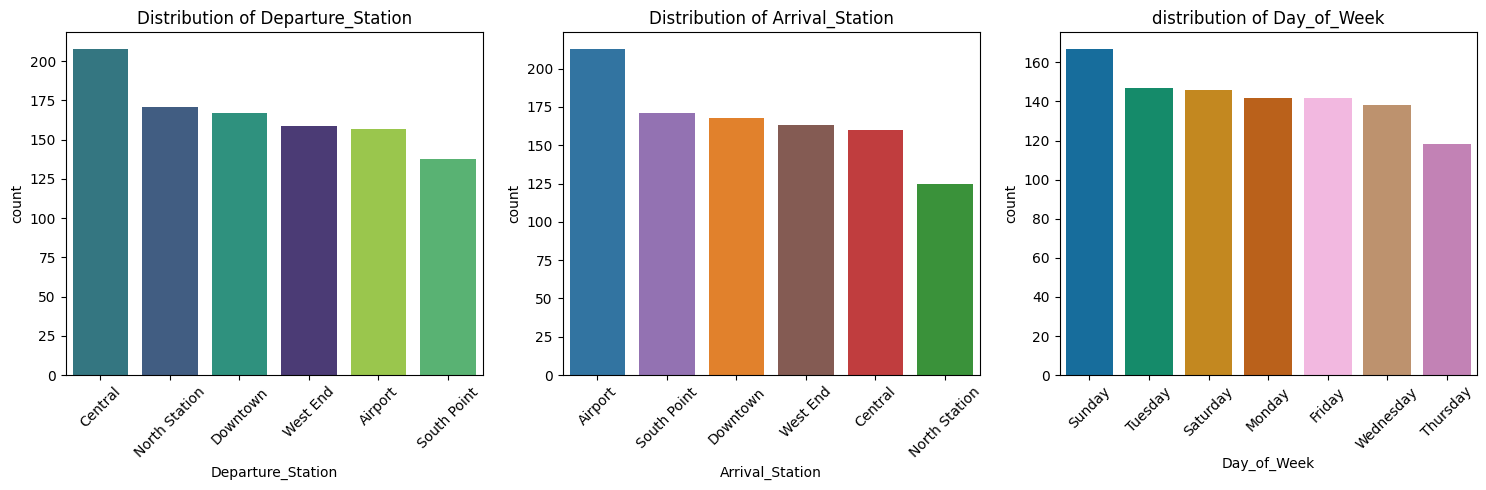

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 5)) # figuresize and axes

departure_station_data = df.groupby('Mode_of_Transport')['Trip_ID'].value_counts().index # mode of transport count by trip id data frame
sns.countplot(data=df, x='Departure_Station',hue='Departure_Station', palette='viridis', order=df['Departure_Station'].value_counts(ascending=False).index, ax=axs[0])
axs[0].set_title('Distribution of Departure_Station')
axs[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Arrival_Station', hue='Arrival_Station', order=df['Arrival_Station'].value_counts(ascending=False).index, ax=axs[1])
axs[1].set_title('Distribution of Arrival_Station')
axs[1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Day_of_Week', hue='Day_of_Week', palette='colorblind', order=df['Day_of_Week'].value_counts(ascending=False).index, ax=axs[2])
axs[2].set_title('distribution of Day_of_Week')
axs[2].tick_params(axis='x', rotation=45)
plt.tight_layout()


The above visual highlights the volume distribution of individual categorical variables, mapping out exactly where trips originate, conclude, and how the transit demand fluctuates day by day across the week.

**Departure Stations**

- **The Insight:** Central station serving as the most popular starting point.

- **Volume Distribution:** North station follows in second place, while South point sees the least amount of departure traffic.

**Arrival Stations**

- **The Insight/Volume Distribution:** The Airport is the absolute busiest destination on the network, seeing the highest volume of arriving passengers. South Point comes in as the second most popular drop-off hub, while North Station sits at the bottom with the lowest arrival count.

**Day of the Week Trends**

- **The Insight:** Weekly travel patterns show that Sunday is actually peak day for transit demand. Tuesday and Saturday follow closely behind, running nearly neck and neck in terms of trip volume. On the other end of the scale, Thursday serves as the quietest day of the week, recording the lowest overall movement.

**Bivariate Analysis**

Bivariate Analysis involves analysing the relationship between two variable

**Feature Enginneer: Route**

Before diving into the Bivariate relationships, let's perform a **Feature Enginneer** step base on Distribution of Departure_Station and Distribution of Arrival_Station from Univriate Analysis. By combining the Departure_Station' and 'Arrival_Station' columns, it creates a new Route variable. This allows to easily track, rank, and visualise busiest commuting corridors.

In [ ]:
# Create Route column
df['Route'] = df['Departure_Station'] + ' - ' + df['Arrival_Station']
df.head(2)

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Route
0,TRIP0001,Ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,West End - Airport
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,North Station - Downtown


**Catigorical vs Numerical**

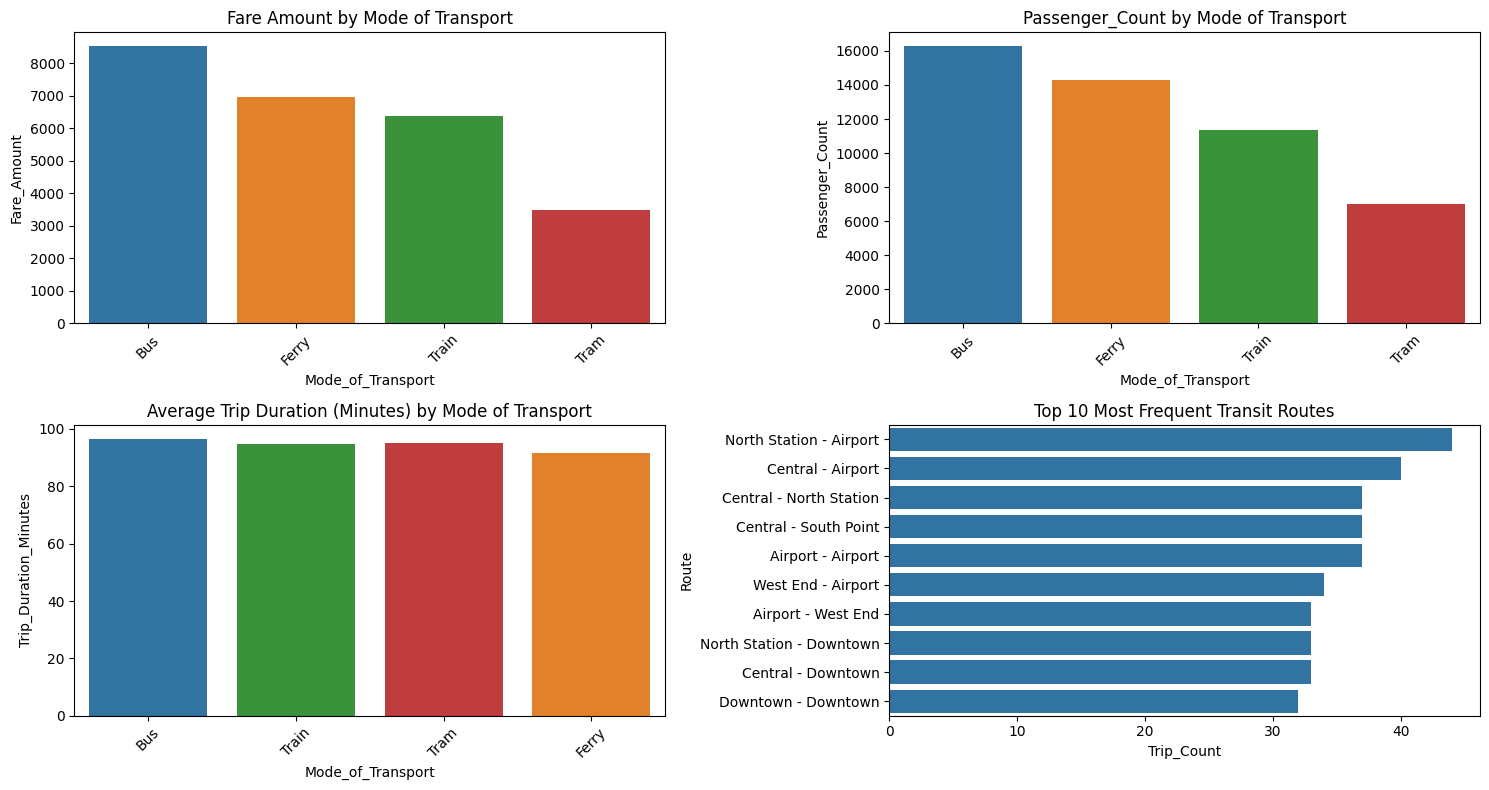

In [ ]:
# Mode_of_Transport by Fare_Amount
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))

modeOfTransByFareAmount = df.groupby('Mode_of_Transport')['Fare_Amount'].sum().reset_index()
sns.barplot(data=modeOfTransByFareAmount, x='Mode_of_Transport', y='Fare_Amount', hue='Mode_of_Transport', errorbar=None, ax=axs[0,0])
axs[0,0].set_title('Fare Amount by Mode of Transport')
axs[0,0].tick_params(axis='x', rotation=45)

modeOfTransByPassenger = df.groupby('Mode_of_Transport')['Passenger_Count'].sum().reset_index()
sns.barplot(data=modeOfTransByPassenger, x='Mode_of_Transport', y='Passenger_Count', hue='Mode_of_Transport', errorbar=None, ax=axs[0,1])
axs[0,1].set_title('Passenger_Count by Mode of Transport')
axs[0,1].tick_params(axis='x', rotation=45)

my_order = ['Bus', 'Train', 'Tram', 'Ferry']
modeOfTransByTripDuraTime = df.groupby('Mode_of_Transport')['Trip_Duration_Minutes'].mean().reset_index()
sns.barplot(data=modeOfTransByTripDuraTime, x='Mode_of_Transport', y='Trip_Duration_Minutes',order=my_order, hue='Mode_of_Transport', errorbar=None, ax=axs[1,0])
axs[1,0].set_title('Average Trip Duration (Minutes) by Mode of Transport')
axs[1,0].tick_params(axis='x', rotation=45)

top_routes = df['Route'].value_counts().head(10).reset_index() # value count and sort
top_routes.columns = ['Route', 'Trip_Count']
sns.barplot(data=top_routes,y='Route',x='Trip_Count', ax=axs[1,1])
axs[1,1].set_title('Top 10 Most Frequent Transit Routes')
plt.tight_layout()


The charts above aggregates MetroMove's performance metrics across all active mode of transport, mapping out total revenue, absolute passenger volume, travel duration efficiency, and route frequencies side-by-side.

**Total Revenue Performance**

- **The Insight:** looking at the financial bottom line, Buses are the heavy hitters, generating the highest total revenue for the business.

- **Revenue Breakdown:** Ferries come in a strong second, with Trains holding the middle ground. Trams, on the other hand, bring in the lowest total revenue, marking least profitable mode of transport.

**Passenger Preference**

- **The Insight:** The total Passenger numbers reveal that Buses are overwhelmingly preferred by customers, pulling in the highest volume of passengers overall. Ferries take second place for popularity, while Trams sit at the bottom of the pile.

**Average Journey Times**

- **The Insight:** The average duration of a trip is remarkably consistent across all options, hovering just under 100 minutes.

- **Efficiency Breakdown:** Buses take the top spot for the longest average journey time, with Trains and Trams following almost identically behind. Ferries clock the quickest average trips, making it the fastest transit option per journey.

**Top 10 Most Frequent Transit Routes**

- **The Insight:** The absolute busiest corridor on the network is North Station to the Airport, followed closely by Central to the Airport. In fact, a quick glance shows that the Airport features in almost half of the top ten busiest routes, confirming it is the primary economic anchor for passenger demand.

- **Operational Quirk:** looking closely at the visualisation, it spots a fascination operational quirk. The route logged as Airport to Airport and Downtown to Downtown. In a public transit setup, these are highly unusual loops. This is potentially minor data inconsistencies where destination was not updated correctly during its shift.

**Numerical vs Numerical**

In [ ]:
df.head(5)

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Route
0,TRIP0001,Ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,West End - Airport
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,North Station - Downtown
2,TRIP0003,Bus,Central,North Station,2024-01-01 06:02:00,91.0,26.312252,100.0,2024-01-01,Tuesday,Central - North Station
3,TRIP0004,Ferry,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,93.0,2024-01-01,Sunday,Downtown - Central
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,23.550152,93.0,2024-01-01,Monday,Downtown - Central


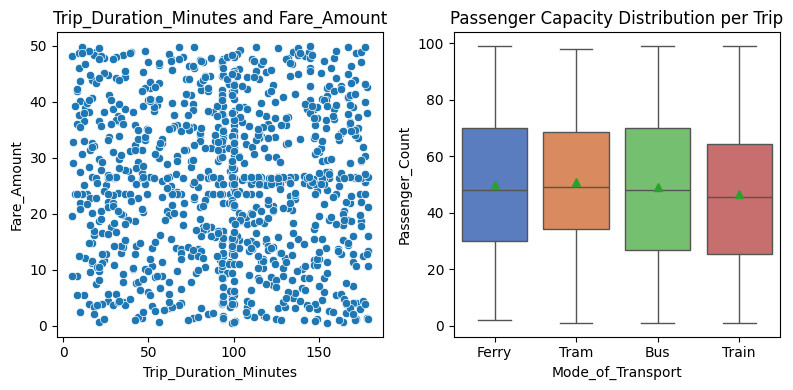

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

sns.scatterplot(data=df, x='Trip_Duration_Minutes', y='Fare_Amount', ax=axs[0])
axs[0].set_title('Trip_Duration_Minutes and Fare_Amount')

sns.boxplot(data=df, x='Mode_of_Transport', y='Passenger_Count', hue="Mode_of_Transport", palette='muted', showmeans=True)
axs[1].set_title('Passenger Capacity Distribution per Trip')
plt.tight_layout();

This section shifts focus to examining how journey lengths impact ticket prices and evaluating how passenger volumes are distributed across different mode of transport.

**Trip Duration vs. Fare Amount**

- **The Insight:** At first glance the scatter reveals a surprising disconnection between the ticket prices and travel times have almost zero direct correlation. Usual assumption is always be longer journeys to cost more, however less than 15 minutes trip is as cost as about 180 journey, resulting in dots scattered evenly across the entire chart.

- **Operational Anomalies:** Looking closely, the data reveals two major operational anomalies. First, noticed the dense vertical line at exactly 100 minutes, this is the clear imprint of the data cleaning, where a large block of missing trip lenths was filled using the median. Second the distinct horizontal bands forming across the middle, particularly around 26.50. This indicates that certain routes are opereting on strict flat-rate pricing structure that completely disregards how long the passenger is actually in transit.

**Passenger Capacity Distribution per Trip**

- **Visual :** This chart shows how crowded vehicles actually get across the different mode of transportation. The green triangles show the statistical average (mean), while the lines in the middle of the boxes show the median.

- **The Insight:** What stands out immediately is how incredibly similar the passenger spreads are across all four modes. Whether it is a Ferry, Tram, Bus, or Train, the typical trip carries a middle-ground average of roughly 45 to 50 passengers, and all of them stretch across a wide range from nearly empty (1 or 2 people) to completely packed (nearly 100 people).

- **Business Takeaway:** From an operational standpoint, this highlights a significant mismatch in asset capacity. A train or ferry can naturally hold far more people than a single bus or tram. Because trains are pulling in the exact same passenger volumes as buses, MetroMove is significantly under-utilising the massive capacity of its rail and water networks. This points to a great opportunity to optimise schedules or run targeted campaigns to fill those higher-capacity vehicles.

**Multivariate**

Multivariate analysis involves analysing the relationship between three or more variables.

**Catigorical/Numerical**

In [ ]:
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Route'],
      dtype='object')

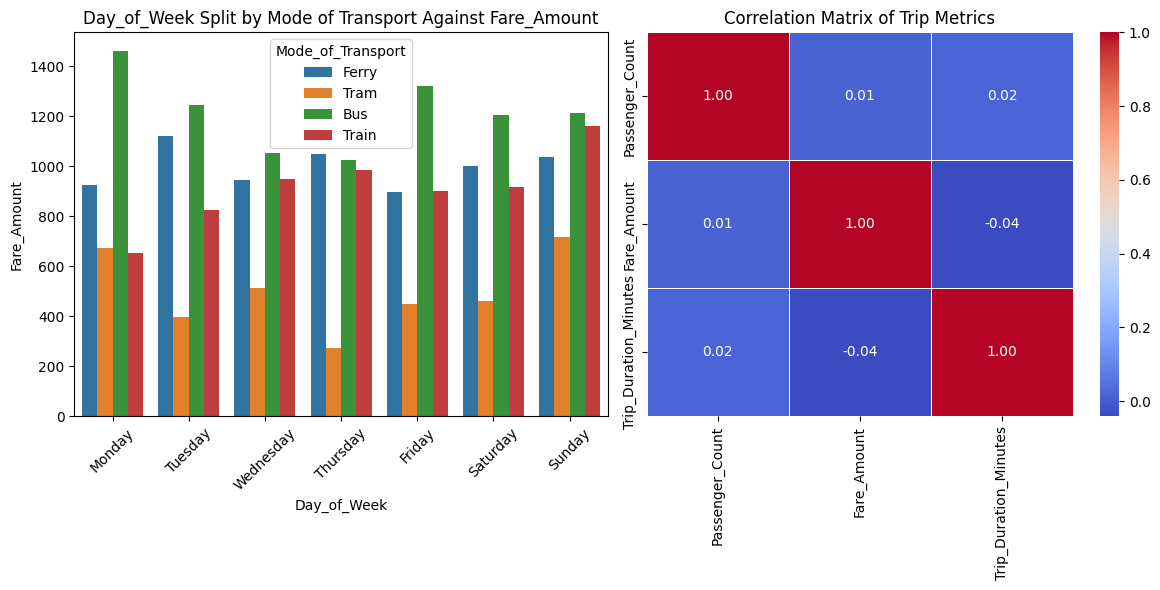

In [ ]:
# Mode_of_Transport and Day_of_Week against Fare_Amount

# Distribution of multiple catigorical against Numerical column
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df, x='Day_of_Week', y='Fare_Amount', hue='Mode_of_Transport', order=day_order, estimator='sum', errorbar=None, ax=axs[0])
axs[0].set_title('Day_of_Week Split by Mode of Transport Against Fare_Amount')
axs[0].tick_params(axis='x', rotation=45)

# correlation matrix for numeric features
corr_matrix = df[['Passenger_Count', 'Fare_Amount', 'Trip_Duration_Minutes']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=axs[1])
axs[1].set_title('Correlation Matrix of Trip Metrics')
plt.tight_layout()

This section evaluates how revenue scales dynamically day by day across different mode of transport alongside a statistical matrix confirming how the core trip metrics interact with one another.

**Weekly Revenue Breakdown by Mode**

- **The Insight:** Buses dominate the charts, bringing in massive revenue almost every day, with huge peaks on Monday and Friday.

- **Revenue Stream:** Follow by Ferries provide a highly relaible, steady stream of daily income. However, tram generate the lowest revenue weekly.

**Correlation Matrix of Trip Metrics**

- **The Insight:** This heatmap is a statistical confirmation of what earlier scatter plot showing, the core operational number is completely disconnected.

- **Statistical Scores:** The near-zero scores (0.01, 0.02, and -0.04) showing that Passenger Count, Fare Amount and Trip Durations share absolutely no relattiohsip.


**Numerical Variables**

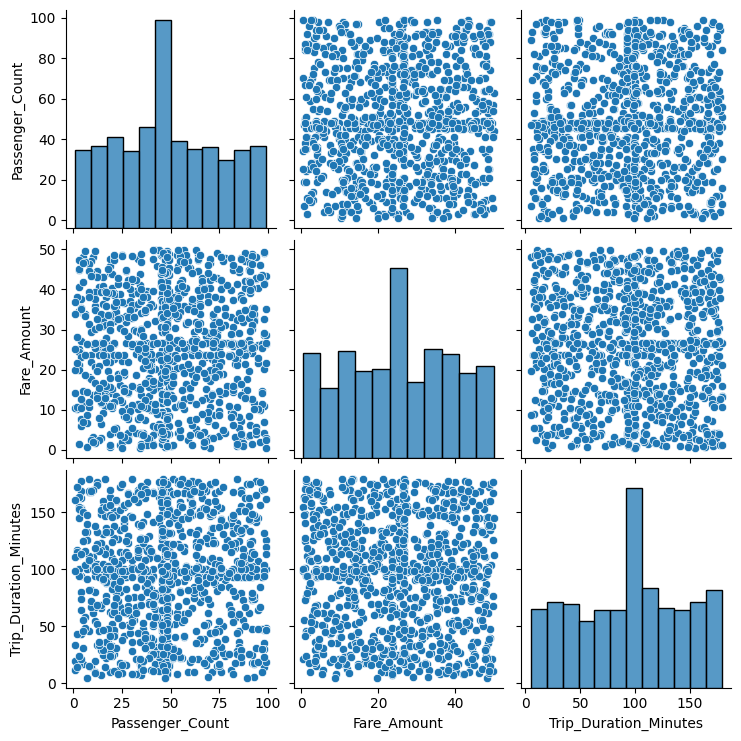

In [ ]:
sns.pairplot(df);

**Multi-Variable Grid Matrix**

This grid pulls numerical metrics together into a single view, that allows simultaneously evaluate interactions between passenger crowds, ticket pricing, and trip lengths.

**Diagonal Distribution Metrics**

- **The Insight:** The diagonal boxes running from the top-left to the bottom-right display the standalone distributions for each numerical variable.

- **Data Imputation Footprints:** The above pair plots clearly highlight the heavy artificial spikes left behind by data cleaning stage where median was used for imputation. This includes the massive central column in the passenger counts, the sharp peak around the £26 price point for fare amount, and the dominant column sitting directly at the 100 minute mark for journey durations.

**Off-Diagonal Interaction Plots**

- **The Insight:** The surrounding scatter plots are static, displaying a completely uniform spread with no visible diagonal trajectories, clusters, or trends, which means low relationship form.

- **Business Takeaway (Operational Red Flag)**: This matrix exposes a major operational red flag for MetroMove's leadership. The network's foundational metrics are completely decoupled from one another, meaning that whether any mode of transport carries 5 passengers or 95, or whether a route runs for 5 minutes or 2 hours, it has zero predictable impact on the final fare amount charged. This highlights an unoptimised pricing structure that fails to reflect actual asset usage, passenger demand, or journey costs.

## **Key Analytical Insights & Red Flag Synthesis**

**Operational Footprints of Data Preprocessing**

- **The Technical Reality:** The univariate and bivariate visualisations reveal distinct vertical and horizontal anomalies that do not reflect organic customer behaviour. Specifically, the sharp, skyscraper-like peak at £26 for fare amounts and the dense vertical accumulation at 100 minutes for trip durations are artificial footprints left behind by our data-cleaning phase.

- **The Analytical Impact:** Because missing values were filled systematically using the median average, a massive cluster of independent journeys was snapped to these exact central markers. Acknowledging these artifacts is crucial, as it separates genuine transit patterns from statistical inputs.

**Revenue, Ridership, & Asset Capacity Mismatches**

- **The Modal Hierarchy:** The multi-variable dashboards reveal that Buses are MetroMove’s core financial engine, capturing the highest overall passenger preference and generating the highest total revenue. Ferries secure a strong second place across both metrics, while Trams consistently lag at the bottom of the pile as the least popular and least profitable mode.

- **Asset Capacity Mismatch:** While individual vehicle types have vastly different physical capacities (a train or ferry can hold far more passengers than a standard bus), our boxplot analysis shows that the actual distribution of passengers per trip is practically identical across all four modes, averaging 45 to 50 passengers. This proves that MetroMove is severely under utilising its highest-capacity assets, moving empty space on trains and ferries while overworking the bus fleet.

**Structural Decoupling of the Pricing Matrix (The Core System Inefficiency)**

- **The Strategic Red Flag:** The pairplot grid and the near zero coefficients in our correlation matrix (0.01, 0.02, and -0.04) statistically confirm a profound, systemic issue: MetroMove’s pricing structure is completely decoupled from operational costs and customer usage.

- **The Proof in the Data:** Under a healthy transit model, longer journey times or higher passenger crowding levels should show a positive linear relationship with higher total fares. Here, however, a trip lasting under 15 minutes cost the exact same as a 3hour journey. This total lack of predictability indicates that certain routes are operating on rigid flat-rate pricing structures that ignore asset wear and tear, fuel usage, or trip distances. This is a critical business leak that actively prevents revenue optimization.

## **Recommendations & Data-Driven Action Plan**

Based on the findings from the Exploratory Data Analysis, the following data-driven strategies are proposed to optimise MetroMove’s fleet/transit operations, modernise its financial structure, and protect profit margins:

**Implement a Dynamic, Distance-Based Pricing Model**

- **The Action:** Redesign the current flat-rate ticket pricing matrix to closely couple fare amounts with trip characteristics. Transition from a static fee structure to a tiered or distance-based pricing model where fares scale linearly with trip duration and distance travelled.

- **The Business Impact:** Eliminating the structural decoupling where 15-minute journeys cost the same as 3-hour trips will plug critical revenue leaks. This ensures that longer journeys appropriately offset the higher fuel, maintenance, and asset wear and tear costs incurred by the network.

**Optimise Modal Asset Allocation (Fleet Rightsizing)**

- **The Action:** Adjust vehicle deployment based on real-world ridership densities. Since 75% of all recorded trips carry fewer than 70 passengers (with a system-wide median of 45 to 50), high-capacity Trains and Ferries are frequently under-utilised.

- **The Business Impact:** MetroMove should introduce smaller, more fuel-efficient shuttle buses or downsized transit units during proven off-peak intervals. Conversely, management should launch targeted marketing campaigns, loyalty incentives, or corporate transit partnerships to actively redirect heavy passenger volumes from overcrowded bus corridors onto under-utilised rail and water networks.

**Capitalise on Weekend Rail Demand**

- **The Action:** Overhaul the current rail scheduling framework to eliminate the glaring operational blind spot where Trains exhibit zero logged weekend operations. Introduce targeted weekend timetables, focusing heavily on leisure commuters, tourist routes, and major event travel.

- **The Business Impact:** Activating the rail network on Saturday and Sunday, traditionally high-volume days for social and recreational transit, creates an entirely new weekend revenue stream, relieving pressure on the overworked bus fleet and maximising the return on expensive rail infrastructure investments.

**Synchronise High-Traffic Airport Corridors**

- **The Action:** Expand and streamline fleet capacity along the network's absolute busiest commuting corridors such as North Station to Airport and Central to Airport.

- **The Business Impact:** Because the Airport acts as the primary economic anchor for passenger demand (featuring in nearly half of the top ten busiest routes), establishing dedicated, high-frequency express shuttle lanes along these routes will improve customer experience, reduce platform crowding, and drastically increase daily ticket turnover.

**Establish Strict Data Governance & Logging Protocols**

- **The Action:** Deploy validation constraints within the transit logging software to eliminate artificial data footprints and operational anomalies. Restrict the system from generating highly unusual circular loops (such as Airport-to-Airport or Downtown-to-Downtown) unless verified as active local shuttles. Furthermore, refine the data capture pipeline to minimize missing data fields, reducing the system's reliance on statistical median imputation.

- **The Business Impact:** Cleaner, higher-fidelity automated logging ensures that future operational dashboards reflect completely organic customer behavior, enabling senior stakeholders to make strategic planning decisions based on pristine data.
